In [1]:
level_depth = 0

In [2]:
# SECONDO BLOCCO — ROBUSTO A NUOVE COLONNE CSV (allineato allo script LDA)
import os
from pathlib import Path
import pandas as pd
import numpy as np
import plotly.io as pio

# Headless-safe Plotly renderer
pio.renderers.default = "notebook_connected" if (os.environ.get("DISPLAY") or os.environ.get("MPLBACKEND")) else "png"

print(f"[INFO] level_depth={level_depth}")

# --- Per-level layout only ---
BASE_LEVEL_DIR = Path(f"/home/students/s328743/Thesis/Smart_crawler_telegram/results/levels/level_{level_depth}")
GRID_DIR       = BASE_LEVEL_DIR / "grid_search_lda"

DF_SAMPLED_CSV = GRID_DIR / f"df_sampled_level_{level_depth}.csv"
GRID_RESULTS   = GRID_DIR / f"grid_search_results_level_{level_depth}.csv"
MODELS_DIR     = GRID_DIR / f"lda_models_level_{level_depth}"
VECT_DIR       = GRID_DIR / f"vectorizers_level_{level_depth}"

# --- Validate required inputs ---
missing = [p for p in (DF_SAMPLED_CSV, GRID_RESULTS, MODELS_DIR) if not p.exists()]
if missing:
    miss_str = "\n  - " + "\n  - ".join(str(m) for m in missing)
    raise FileNotFoundError(f"Required paths/files not found for level {level_depth}:{miss_str}")

print(f"[INFO] DF_SAMPLED_CSV = {DF_SAMPLED_CSV}")
print(f"[INFO] GRID_RESULTS   = {GRID_RESULTS}")
print(f"[INFO] MODELS_DIR     = {MODELS_DIR}")

# --- Load dataframes ---
df_sampled = pd.read_csv(DF_SAMPLED_CSV)
df_grid    = pd.read_csv(GRID_RESULTS)

# ================== ADATTAMENTO ALLO SCHEMA ==================
metric_candidates = [
    "coherence_cv", "coherence_npmi", "diversity", "balance", "avg_score_robust",
]
present_metrics = [m for m in metric_candidates if m in df_grid.columns]
print("[INFO] Metriche trovate nel CSV:", present_metrics)

def _to_float64(s: pd.Series) -> pd.Series:
    return pd.to_numeric(s, errors="coerce").astype("float64")

def robust_minmax_series(values: pd.Series, q_low=0.10, q_high=0.90) -> pd.Series:
    s = _to_float64(values)
    lo, hi = s.quantile(q_low), s.quantile(q_high)
    if not np.isfinite(lo) or not np.isfinite(hi) or hi <= lo:
        return pd.Series(np.full(len(s), 0.5, dtype=np.float64), index=s.index)
    return ((s - lo) / (hi - lo)).clip(0, 1).astype("float64")

def compute_avg_score_robust_in_memory(df: pd.DataFrame) -> pd.Series:
    parts = []
    weights = []

    # 1) coherence_cv → robust minmax
    if "coherence_cv" in df.columns:
        parts.append(robust_minmax_series(df["coherence_cv"])); weights.append(0.4)

    # 2) diversity → robust minmax
    if "diversity" in df.columns:
        parts.append(robust_minmax_series(df["diversity"]));    weights.append(0.3)

    # 3) coherence_npmi ∈ [-1,1] → mappo in [0,1], poi robust minmax
    if "coherence_npmi" in df.columns:
        npmi01 = ((_to_float64(df["coherence_npmi"]) + 1.0) / 2.0).clip(0, 1)
        parts.append(robust_minmax_series(npmi01));             weights.append(0.2)

    # 4) balance → robust minmax
    if "balance" in df.columns:
        parts.append(robust_minmax_series(df["balance"]));      weights.append(0.1)

    if not parts:
        return pd.Series(np.nan, index=df.index, dtype="float64")

    wsum = sum(weights)
    weights = [w / wsum for w in weights]
    stacked = np.vstack([s.fillna(0.0).to_numpy(dtype="float64") for s in parts])
    avg = np.average(stacked, axis=0, weights=weights)
    return pd.Series(avg, index=df.index, dtype="float64")

# Se NON c'è già la colonna aggregata, la calcolo in RAM e la salvo come singola colonna finale
if "avg_score_robust" not in df_grid.columns:
    avg_ser = compute_avg_score_robust_in_memory(df_grid)
    df_grid["avg_score_robust"] = avg_ser  # <-- scrivo SOLO questa, nessuna colonna d’appoggio

# Fallback nel caso estremo di CSV senza le metriche “nuove”
summary_score_col = "avg_score_robust"
if "avg_score_robust" not in df_grid.columns:
    usable = [c for c in present_metrics if c not in {"avg_score_robust"}]
    usable_num = [c for c in usable if pd.api.types.is_numeric_dtype(df_grid[c])]
    if usable_num:
        df_grid["avg_score_fallback"] = df_grid[usable_num].mean(axis=1)
        summary_score_col = "avg_score_fallback"
        print(f"[INFO] Usata media semplice su: {usable_num}")
    else:
        raise ValueError("Nessuna metrica valutabile trovata nel CSV.")

print(f"[INFO] Metrica di selezione = {summary_score_col}")

# ============== SELEZIONE BEST MODEL PER OGNI METRICA DISPONIBILE ==============
def best_row_by(colname: str):
    if colname in df_grid.columns:
        return df_grid.sort_values(by=colname, ascending=False).iloc[0]
    return None

targets = [("avg_score", summary_score_col)]
for m in ["coherence_cv","coherence_npmi","diversity","balance"]:
    if m in df_grid.columns:
        targets.append((m, m))

best_models = {}
for alias, col in targets:
    row = best_row_by(col)
    if row is not None:
        best_models[alias] = row

if not best_models:
    raise ValueError("Nessun best model ricavabile: CSV privo di colonne metriche utili.")

# ---------- RIEPILOGO "BEST": metriche + info utili (solo colonne esistenti) ----------
wanted_metrics = list({c for _, c in targets})
wanted_params  = [
    # LDA params / conteggi
    "k","n_components","learning_method","batch_size","max_iter","learning_decay",
    "vocab_size","n_docs","effective_topics","min_topic","max_topic",
    # label/path
    "suffix","model_path","vectorizer_path","model_name"
]

rows = []
for which_best, row in best_models.items():
    rec = {"which_best": which_best}
    # metriche+params solo se esistono
    for col in wanted_metrics + wanted_params:
        if col in df_grid.columns:
            rec[col] = row.get(col)
    # compat: se ho model_name e non model_path, costruisco path in MODELS_DIR
    if "model_name" in rec and "model_path" not in rec:
        rec["model_path"] = str(MODELS_DIR / rec["model_name"])
    rows.append(rec)

best_summary = pd.DataFrame(rows)

ordered_cols = (
    ["which_best"]
    + [c for c in wanted_metrics if c in best_summary.columns]
    + [c for c in wanted_params  if c in best_summary.columns]
)
best_summary = best_summary.loc[:, ordered_cols]

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)
print("\n[INFO] Best models summary (metriche + parametri disponibili):")
print(best_summary.to_string(index=False, float_format=lambda x: f"{x:.4f}" if isinstance(x, float) else str(x)))

# Expose for later cells
print("[INFO] Data and grid loaded. Vars:")
print(f"  MODELS_DIR = {MODELS_DIR}")
print(f"  DF_SAMPLED_CSV = {DF_SAMPLED_CSV}")
print(f"  GRID_RESULTS = {GRID_RESULTS}")
print("  best_models keys =", list(best_models.keys()))

print("df_sampled sampled")
print(df_sampled.head())


[INFO] level_depth=0
[INFO] DF_SAMPLED_CSV = /home/students/s328743/Thesis/Smart_crawler_telegram/results/levels/level_0/grid_search_lda/df_sampled_level_0.csv
[INFO] GRID_RESULTS   = /home/students/s328743/Thesis/Smart_crawler_telegram/results/levels/level_0/grid_search_lda/grid_search_results_level_0.csv
[INFO] MODELS_DIR     = /home/students/s328743/Thesis/Smart_crawler_telegram/results/levels/level_0/grid_search_lda/lda_models_level_0
[INFO] Metriche trovate nel CSV: ['coherence_cv', 'coherence_npmi', 'diversity', 'balance', 'avg_score_robust']
[INFO] Metrica di selezione = avg_score_robust

[INFO] Best models summary (metriche + parametri disponibili):
    which_best  diversity  avg_score_robust  coherence_npmi  balance  coherence_cv  k learning_method  batch_size  max_iter  learning_decay  vocab_size  n_docs  effective_topics  min_topic  max_topic                                            suffix                                                                                     

[INFO] Visualizzo il best model per COHERENCE_CV (WordCount + Importance)
[INFO] Candidate paths (max 6):
  - ../results/levels/level_0/grid_search_lda/bertopic_models_level_0/LDA_k33_ng1-2_minDF30_maxDF0.9_maxF50000_decay0.7.joblib
  - /home/students/s328743/Thesis/Smart_crawler_telegram/results/levels/level_0/grid_search_lda/lda_models_level_0/LDA_k33_ng1-2_minDF30_maxDF0.9_maxF50000_decay0.7.joblib
[INFO] Carico LDA da: /home/students/s328743/Thesis/Smart_crawler_telegram/results/levels/level_0/grid_search_lda/lda_models_level_0/LDA_k33_ng1-2_minDF30_maxDF0.9_maxF50000_decay0.7.joblib
[INFO] LDA OK: K=33, |V|=3757
[INFO] Vocabolario da VECT_DIR: |V|=3757


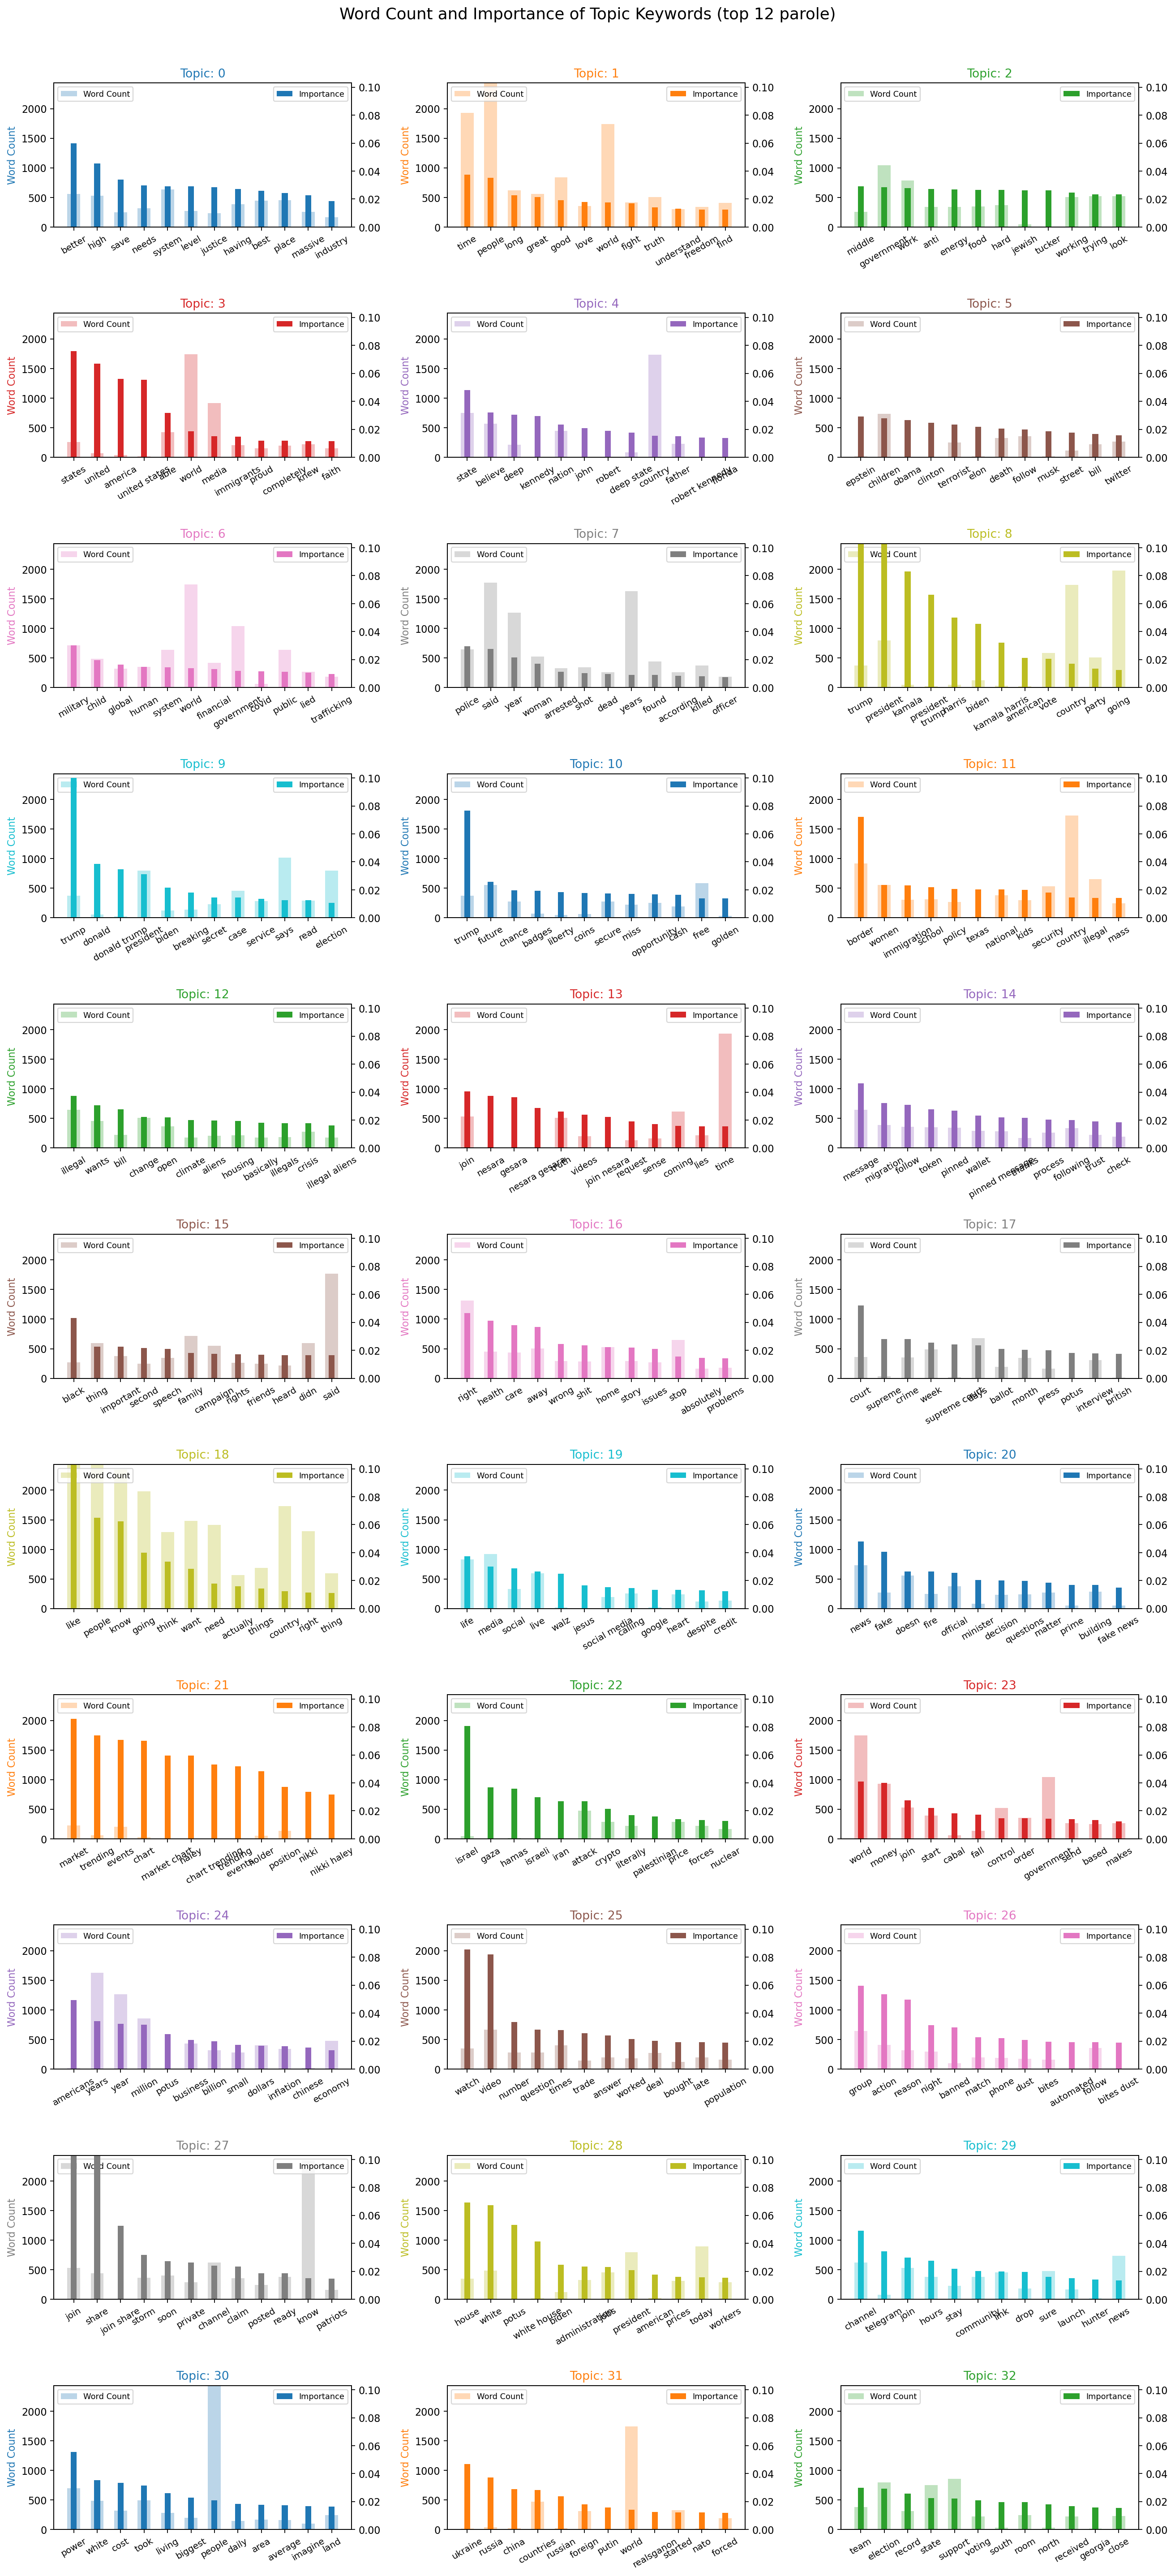

In [11]:
# === COHERENCE_CV — LDA: Word Count + Importance (scikit-learn LDA, niente show_topics) ===
from pathlib import Path
import joblib
import numpy as np
import pandas as pd
import math, textwrap

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

print("[INFO] Visualizzo il best model per COHERENCE_CV (WordCount + Importance)")

key = "coherence_cv"
if key not in best_models:
    raise KeyError(f"Metrica {key} non presente in best_models. Presenti: {list(best_models.keys())}")
row = best_models[key]

# ---------- 1) Risoluzione del path del modello ----------
suffix = str(row.get("suffix") or "")
candidate_paths = []
if isinstance(row.get("model_path"), str):
    candidate_paths.append(Path(row["model_path"]))
if suffix:
    candidate_paths.append(Path(MODELS_DIR) / f"{suffix}.joblib")
try:
    if suffix:
        for p in sorted(Path(MODELS_DIR).iterdir()):
            if suffix in p.name:
                candidate_paths.append(p)
except FileNotFoundError:
    pass

seen, unique_candidates = set(), []
for p in candidate_paths:
    if p not in seen:
        seen.add(p); unique_candidates.append(p)

print("[INFO] Candidate paths (max 6):")
for cp in unique_candidates[:6]:
    print("  -", cp)

model_path = next((p for p in unique_candidates if p.exists()), None)
if model_path is None:
    raise FileNotFoundError(f"Nessun file modello trovato. MODELS_DIR={MODELS_DIR}, suffix='{suffix}'")
print(f"[INFO] Carico LDA da: {model_path}")

# ---------- 2) Carico LDA (scikit-learn) ----------
loaded = joblib.load(model_path)
if not (hasattr(loaded, "components_") and type(loaded).__name__ == "LatentDirichletAllocation"):
    raise TypeError("Oggetto caricato non è una LDA scikit-learn compatibile.")
lda_model = loaded
K, V = lda_model.components_.shape
print(f"[INFO] LDA OK: K={K}, |V|={V}")

# ---------- 3) Vectorizer + vocabolario (serve per Word Count) ----------
vectorizer = None
vocabulary = None

vocab_path = row.get("vectorizer_path")
if isinstance(vocab_path, str) and Path(vocab_path).exists():
    try:
        vectorizer = joblib.load(vocab_path)
        vocabulary = (vectorizer.get_feature_names_out()
                      if hasattr(vectorizer, "get_feature_names_out")
                      else vectorizer.get_feature_names())
        print(f"[INFO] Vocabolario da vectorizer_path: |V|={len(vocabulary)}")
    except Exception as e:
        print(f"[WARN] Errore nel caricamento del vectorizer: {e}")

if vocabulary is None and suffix:
    guess_vec = Path(VECT_DIR) / f"vectorizer_{suffix}.joblib"
    if guess_vec.exists():
        try:
            vectorizer = joblib.load(guess_vec)
            vocabulary = (vectorizer.get_feature_names_out()
                          if hasattr(vectorizer, "get_feature_names_out")
                          else vectorizer.get_feature_names())
            print(f"[INFO] Vocabolario da VECT_DIR: |V|={len(vocabulary)}")
        except Exception as e:
            print(f"[WARN] Errore nel caricamento del vectorizer (guess): {e}")

if vocabulary is None or vectorizer is None:
    raise RuntimeError("Vectorizer/vocabolario mancante: serve per calcolare i Word Count.")

if len(vocabulary) != V:
    raise ValueError(f"Incongruenza |V|: vocab={len(vocabulary)} vs components_={V}")

# ---------- 4) Word Count dal corpus (df_sampled['text']) ----------
if 'text' not in df_sampled.columns:
    raise KeyError("df_sampled non contiene la colonna 'text'.")

X_counts = vectorizer.transform(df_sampled['text'].astype(str))  # |D| x |V| (sparse)
word_counts_vec = np.asarray(X_counts.sum(axis=0)).ravel()       # |V|
assert word_counts_vec.shape[0] == V

# ---------- 5) Costruisco DF (word, topic_id, importance, word_count) ----------
def build_topics_df(lda_model, vocabulary, word_counts_vec, topn=12):
    comps = lda_model.components_.astype(np.float64)              # [K, V]
    K, V = comps.shape
    rows = []
    for k in range(K):
        row = comps[k]
        S = row.sum() if row.sum() > 0 else 1.0
        probs = row / S                                           # importance = P(word|topic)
        top_idx = np.argsort(row)[::-1][:topn]
        for j in top_idx:
            rows.append([str(vocabulary[j]), int(k), float(probs[j]), int(word_counts_vec[j])])
    return pd.DataFrame(rows, columns=['word','topic_id','importance','word_count'])

TOPN = 12
df = build_topics_df(lda_model, vocabulary, word_counts_vec, topn=TOPN)

# ---------- 6) Plot Matplotlib: doppio asse per topic (Word Count + Importance) ----------
n_topics_to_show = min(K, 180)

# griglia: più topic => più colonne per non allargare i pannelli
cols = 4 if n_topics_to_show >= 40 else (3 if n_topics_to_show >= 20 else 2)
rows = math.ceil(n_topics_to_show / cols)

fig, axes = plt.subplots(rows, cols, figsize=(cols*5.5, rows*3.2), dpi=160, squeeze=False)
palette = list(mcolors.TABLEAU_COLORS.values())

# limiti "robusti" globali (99° percentile) per coerenza assi
imp_max = float(np.percentile(df['importance'], 99)) if len(df) else 0.03
imp_max = max(0.03, round(imp_max, 3))
cnt_max = int(np.percentile(df['word_count'], 99)) if len(df) else 100
cnt_max = max(10, cnt_max)

for i in range(n_topics_to_show):
    r, c = divmod(i, cols)
    ax = axes[r][c]
    di = df.loc[df.topic_id == i].sort_values('importance', ascending=False)
    if di.empty:
        ax.axis('off'); continue

    # x: parole (wrappate per leggibilità)
    words = [textwrap.fill(w, width=14) for w in di['word'].tolist()]
    counts = di['word_count'].tolist()
    imps   = di['importance'].tolist()
    color  = palette[i % len(palette)]

    # Barre Word Count (asse sinistro)
    ax.bar(words, counts, color=color, width=0.55, alpha=0.30, label='Word Count')
    ax.set_ylabel('Word Count', color=color)
    ax.set_ylim(0, cnt_max)
    ax.tick_params(axis='y', left=False)
    ax.tick_params(axis='x', rotation=30, labelsize=9)

    # Barre Importance (asse destro)
    ax_twin = ax.twinx()
    ax_twin.bar(words, imps, color=color, width=0.25, label='Importance')
    ax_twin.set_ylim(0, imp_max)

    ax.set_title(f'Topic: {i}', color=color, fontsize=12)

    # legende piccole ai lati
    ax.legend(loc='upper left', fontsize=8)
    ax_twin.legend(loc='upper right', fontsize=8)

# pannelli vuoti (se i < rows*cols)
for j in range(n_topics_to_show, rows*cols):
    r, c = divmod(j, cols)
    axes[r][c].axis('off')

fig.tight_layout(w_pad=2.0, h_pad=2.0)
fig.suptitle(f'Word Count and Importance of Topic Keywords (top {TOPN} parole)', fontsize=16, y=1.02)
plt.show()
